In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

In [3]:
churn_data=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")


In [4]:
churn_data["TotalCharges"] = pd.to_numeric(churn_data["TotalCharges"], errors='coerce')
churn_data["MonthlyCharges"] = pd.to_numeric(churn_data["MonthlyCharges"], errors='coerce')

In [5]:
churn_data["SeniorCitizen"] = churn_data["SeniorCitizen"].map({1: "Yes", 0: "No"})

In [6]:
churn_data["Churn"] = churn_data["Churn"].map({"No": 0, "Yes": 1})


In [7]:
print("\nMissing values:")
print(churn_data.isnull().sum())


Missing values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [10]:
churn_data = churn_data.dropna(subset=["TotalCharges"])

In [11]:
print(churn_data.isnull().sum())
print(churn_data.shape)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
(7032, 21)


In [8]:
X = churn_data.drop(columns=["Churn"])
y = churn_data["Churn"]

# Separate numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumeric columns:", numeric_features)
print("Categorical columns:", categorical_features)


Numeric columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [12]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, random_state=42, class_weight="balanced"
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=400, random_state=42, class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}

results = []
fitted_models = {}


In [15]:
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline

    y_pred = pipeline.predict(X_test)

    # probabilities if available
    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = np.nan

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc
    })

results_churn = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

print("\nModel Comparison:")
print(results_churn)



Model Comparison:
                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
3    Gradient Boosting  0.804116   0.672535  0.510695  0.580547  0.845750
1        Random Forest  0.788502   0.626667  0.502674  0.557864  0.827634
2          Extra Trees  0.778566   0.601307  0.491979  0.541176  0.817542
4                  KNN  0.764372   0.554974  0.566845  0.560847  0.802556
0  Logistic Regression  0.753016   0.524164  0.754011  0.618421  0.840921


In [18]:
best_model_name = results_churn.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

print(f"\nBest model based on Accuracy: {best_model_name}")
print(f"Best Accuracy: {results_churn.iloc[0]['Accuracy']:.4f}")



Best model based on Accuracy: Gradient Boosting
Best Accuracy: 0.8041


In [19]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=15,
    random_state=42,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm.importances_mean
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 most important factors affecting churn:")
print(importance_df.head(10))

most_important_factor = importance_df.iloc[0]["Feature"]
print(f"\nMost important factor affecting churn: {most_important_factor}")



Top 10 most important factors affecting churn:
             Feature  Importance
5             tenure    0.043388
15          Contract    0.030565
8    InternetService    0.014762
9     OnlineSecurity    0.011545
17     PaymentMethod    0.010740
12       TechSupport    0.007145
7      MultipleLines    0.007097
16  PaperlessBilling    0.005252
19      TotalCharges    0.004826
18    MonthlyCharges    0.003738

Most important factor affecting churn: tenure


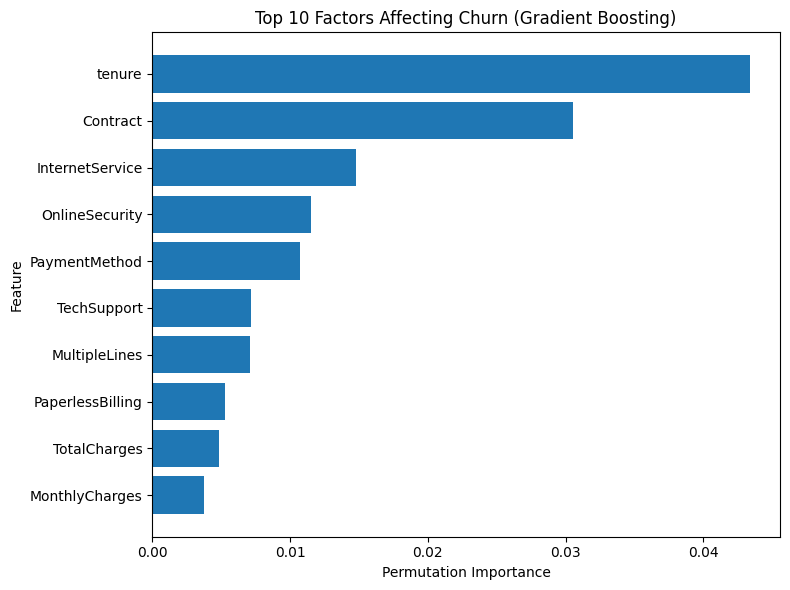

In [20]:
top_n = 10
top_features = importance_df.head(top_n).sort_values(by="Importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.title(f"Top {top_n} Factors Affecting Churn ({best_model_name})")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [21]:
# Best model 
final_model = fitted_models["Gradient Boosting"]

# Predict leave/stay for each row in the test set
y_pred = final_model.predict(X_test)

# Predict probability of churn (class 1 = leave)
y_prob = final_model.predict_proba(X_test)[:, 1]

# Build a results table
results = X_test.copy()
results["Actual_Churn"] = y_test.values
results["Predicted_Churn"] = y_pred
results["Churn_Probability"] = y_prob

# Map labels to readable text
results["Predicted_Label"] = results["Predicted_Churn"].map({0: "Stay", 1: "Leave"})
results["Actual_Label"] = results["Actual_Churn"].map({0: "Stay", 1: "Leave"})

# Show the first few predictions
print(results[["Actual_Label", "Predicted_Label", "Churn_Probability"]].head(10))

     Actual_Label Predicted_Label  Churn_Probability
437          Stay            Stay           0.046786
2280         Stay           Leave           0.738369
2235         Stay            Stay           0.060932
4460         Stay            Stay           0.344252
3761         Stay            Stay           0.045216
5748         Stay           Leave           0.568600
3568         Stay            Stay           0.446030
2976         Stay            Stay           0.103018
5928         Stay            Stay           0.027085
1639        Leave            Stay           0.341811


In [23]:
# customers most likely to leave
high_risk_customers = results.sort_values("Churn_Probability", ascending=False)
print(high_risk_customers[["Actual_Label", "Predicted_Label", "Churn_Probability"]].head(20))

     Actual_Label Predicted_Label  Churn_Probability
3380        Leave           Leave           0.893698
6866        Leave           Leave           0.887019
4585        Leave           Leave           0.869621
6623        Leave           Leave           0.862241
2464        Leave           Leave           0.853908
383         Leave           Leave           0.850053
642         Leave           Leave           0.849343
6633        Leave           Leave           0.846220
2631        Leave           Leave           0.845372
6365        Leave           Leave           0.845372
2797        Leave           Leave           0.844921
1731        Leave           Leave           0.839094
2246        Leave           Leave           0.838042
2275        Leave           Leave           0.837672
2900        Leave           Leave           0.836057
1739        Leave           Leave           0.834688
2927         Stay           Leave           0.834688
809         Leave           Leave           0.